In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

NEUES PROBLEM: KLASSIFIKATION MIT LABEL NOISE


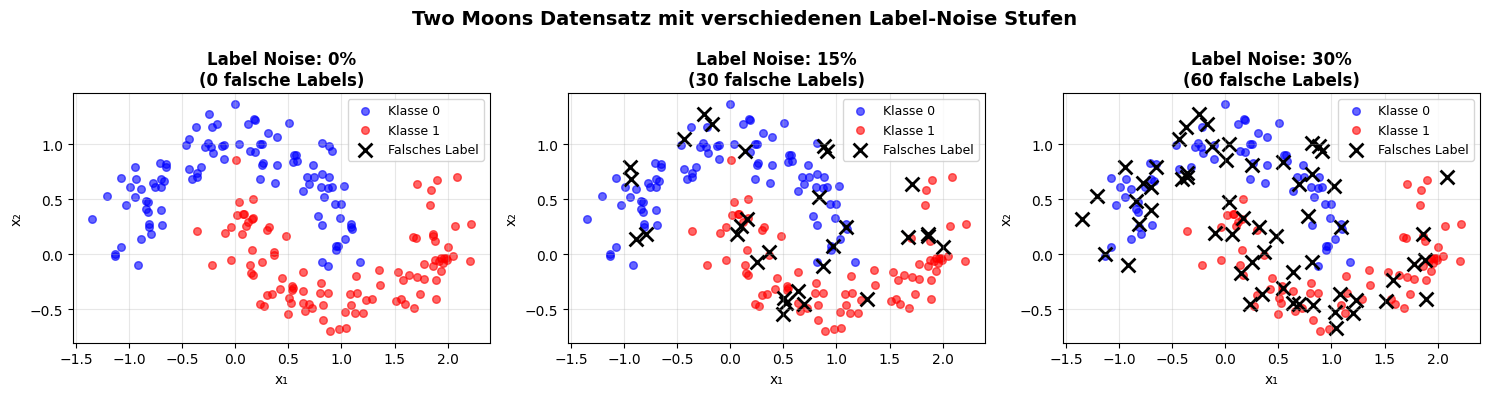


WARUM LABEL NOISE?
──────────────────
• Bei Label Noise = 0%: Überparameterisierte Modelle funktionieren einfach gut
• Bei Label Noise > 0%: Modell muss entscheiden ob es das Rauschen "auswendig lernt"
                        oder die wahre Struktur findet
• Am Interpolation-Threshold: Modell lernt ALLE Labels auswendig (auch die falschen!)
                              → Schlechteste Generalisierung
• Im Overparameterized Regime: Modell hat genug Kapazität für eine "glatte" Lösung
                               → Ignoriert effektiv das Label-Rauschen



In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# PROBLEM 2: "TWO MOONS" MIT LABEL NOISE
# ═══════════════════════════════════════════════════════════════════════════
# 
# Warum dieses Problem?
# - Nichtlinear trennbar → braucht ausreichend komplexes Modell
# - Label Noise verstärkt Double Descent Effekt dramatisch!
# - Gut visualisierbar in 2D

from sklearn.datasets import make_moons

def generate_noisy_moons(n_samples, noise=0.2, label_noise=0.1):
    """
    Generiert Two-Moons Datensatz mit Label-Rauschen.
    
    Label Noise bedeutet: Ein Teil der Labels wird zufällig geflippt!
    Das simuliert fehlerhafte Annotationen in echten Daten.
    """
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=42)
    X = X.astype(np.float32)
    
    # Label Noise hinzufügen
    n_flip = int(n_samples * label_noise)
    flip_indices = np.random.choice(n_samples, n_flip, replace=False)
    y_noisy = y.copy()
    y_noisy[flip_indices] = 1 - y_noisy[flip_indices]  # 0→1, 1→0
    
    return X, y_noisy.astype(np.float32), y  # Auch originale Labels zurückgeben

# Visualisierung
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, label_noise in enumerate([0.0, 0.15, 0.30]):
    X, y_noisy, y_true = generate_noisy_moons(200, noise=0.15, label_noise=label_noise)
    
    ax = axes[idx]
    
    # Punkte mit korrekten Labels
    correct = y_noisy == y_true
    ax.scatter(X[correct & (y_noisy==0), 0], X[correct & (y_noisy==0), 1], 
               c='blue', alpha=0.6, s=30, label='Klasse 0')
    ax.scatter(X[correct & (y_noisy==1), 0], X[correct & (y_noisy==1), 1], 
               c='red', alpha=0.6, s=30, label='Klasse 1')
    
    # Punkte mit falschen Labels (größer und mit Kreuz markiert)
    wrong = ~correct
    ax.scatter(X[wrong, 0], X[wrong, 1], 
               c='black', marker='x', s=100, linewidths=2, label='Falsches Label')
    
    ax.set_title(f'Label Noise: {label_noise*100:.0f}%\n({wrong.sum()} falsche Labels)', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Two Moons Datensatz mit verschiedenen Label-Noise Stufen', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
WARUM LABEL NOISE?
──────────────────
• Bei Label Noise = 0%: Überparameterisierte Modelle funktionieren einfach gut
• Bei Label Noise > 0%: Modell muss entscheiden ob es das Rauschen "auswendig lernt"
                        oder die wahre Struktur findet
• Am Interpolation-Threshold: Modell lernt ALLE Labels auswendig (auch die falschen!)
                              → Schlechteste Generalisierung
• Im Overparameterized Regime: Modell hat genug Kapazität für eine "glatte" Lösung
                               → Ignoriert effektiv das Label-Rauschen
""")

ANALYSE: Wann konvergiert jedes Modell?
Width=  3 (  25 params) [UNDER ]: Train-Varianz=0.1222, Test-Varianz=0.1639 → ✗ NICHT STABIL
Width= 10 ( 151 params) [OVER  ]: Train-Varianz=0.2508, Test-Varianz=0.1361 → ✗ NICHT STABIL
Width= 30 (1051 params) [OVER  ]: Train-Varianz=0.3090, Test-Varianz=0.1224 → ✗ NICHT STABIL
Width=100 (10501 params) [OVER  ]: Train-Varianz=0.5911, Test-Varianz=0.0595 → ✗ NICHT STABIL
Width=200 (41001 params) [OVER  ]: Train-Varianz=0.2486, Test-Varianz=0.0059 → ✗ NICHT STABIL


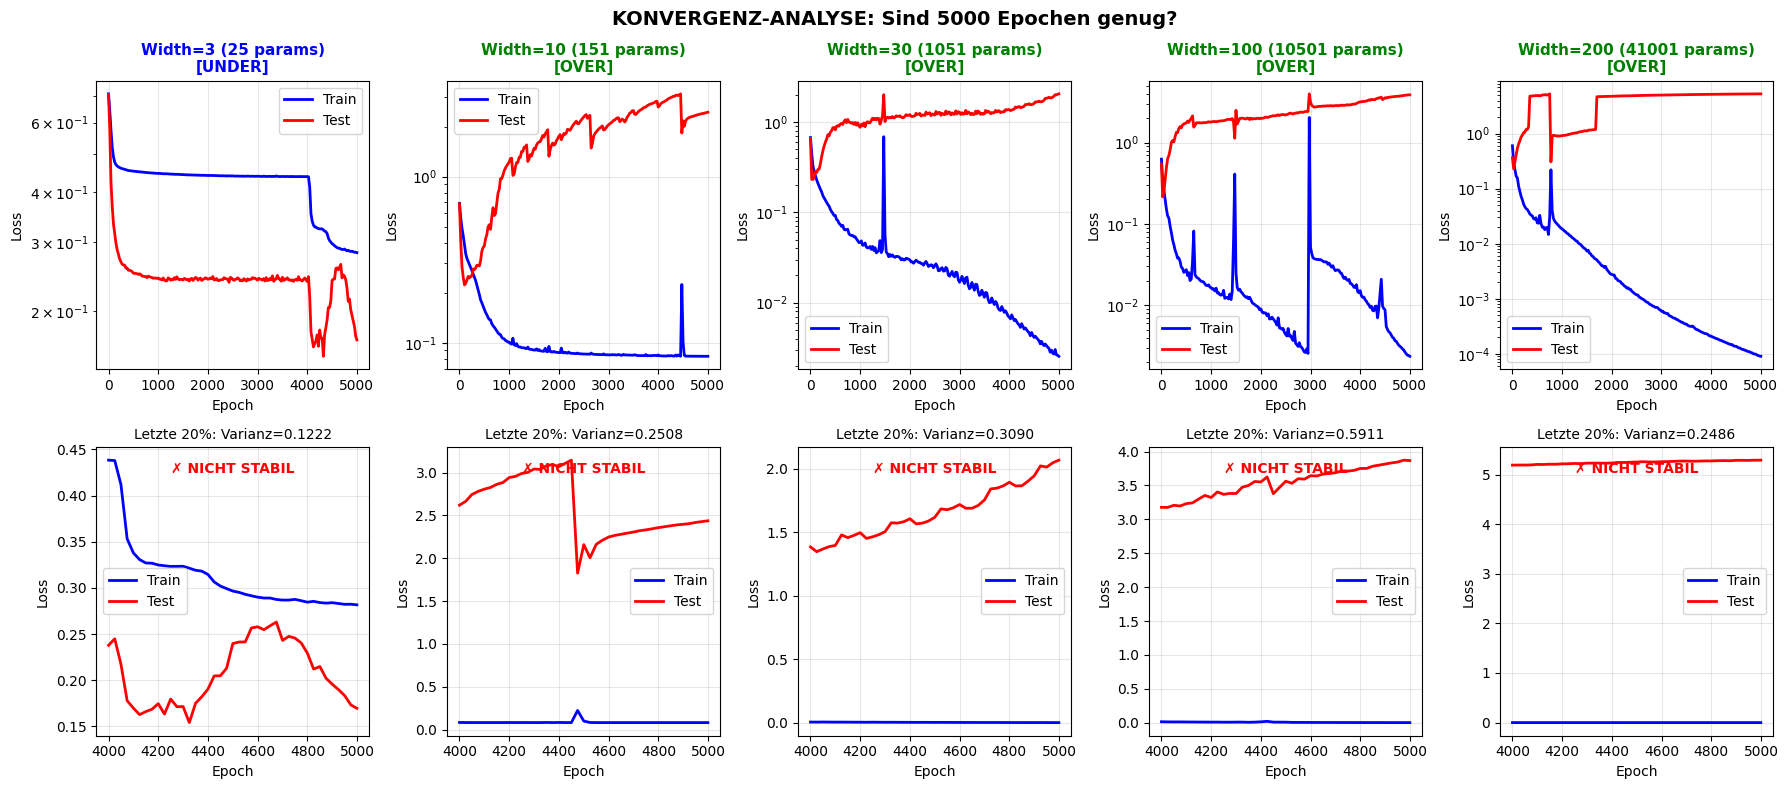

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# EXPERIMENT 1: LERNKURVEN FÜR VERSCHIEDENE MODELLGRÖSSEN
# ═══════════════════════════════════════════════════════════════════════════

def generate_noisy_moons(n_samples, noise=0.2, label_noise=0.1):
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=42)
    X = X.astype(np.float32)
    n_flip = int(n_samples * label_noise)
    flip_indices = np.random.choice(n_samples, n_flip, replace=False)
    y_noisy = y.copy()
    y_noisy[flip_indices] = 1 - y_noisy[flip_indices]
    return X, y_noisy.astype(np.float32), y.astype(np.float32)

class ClassifierMLP(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, width),
            nn.ReLU(),
            nn.Linear(width, width),
            nn.ReLU(),
            nn.Linear(width, 1),
            nn.Sigmoid()
        )
        self.n_params = sum(p.numel() for p in self.parameters())
        self.width = width
    
    def forward(self, x):
        return self.net(x)

def train_with_history(model, X_train, y_train, X_test, y_test, 
                       epochs=5000, lr=0.01, log_every=50):
    """
    Trainiert und speichert KOMPLETTE Lernkurve.
    """
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train).reshape(-1, 1)
    X_test_t = torch.FloatTensor(X_test)
    y_test_t = torch.FloatTensor(y_test).reshape(-1, 1)
    
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    history = {
        'epoch': [],
        'train_loss': [],
        'test_loss': [],
        'train_acc': [],
        'test_acc': []
    }
    
    for epoch in range(epochs):
        # Training Step
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()
        
        # Logging
        if epoch % log_every == 0 or epoch == epochs - 1:
            model.eval()
            with torch.no_grad():
                train_pred = model(X_train_t)
                test_pred = model(X_test_t)
                
                train_loss = criterion(train_pred, y_train_t).item()
                test_loss = criterion(test_pred, y_test_t).item()
                train_acc = ((train_pred > 0.5) == y_train_t).float().mean().item()
                test_acc = ((test_pred > 0.5) == y_test_t).float().mean().item()
            
            history['epoch'].append(epoch)
            history['train_loss'].append(train_loss)
            history['test_loss'].append(test_loss)
            history['train_acc'].append(train_acc)
            history['test_acc'].append(test_acc)
    
    return history

# Daten generieren
n_samples = 80
X, y_noisy, y_true = generate_noisy_moons(n_samples, noise=0.15, label_noise=0.15)
X_train, X_test, y_train_noisy, y_test = train_test_split(X, y_noisy, test_size=0.3, random_state=42)
_, _, _, y_test_true = train_test_split(X, y_true, test_size=0.3, random_state=42)

# Verschiedene Modellgrößen testen
widths_to_analyze = [3, 10, 30, 100, 200]

fig, axes = plt.subplots(2, len(widths_to_analyze), figsize=(18, 8))

print("ANALYSE: Wann konvergiert jedes Modell?")
print("=" * 80)

for idx, width in enumerate(widths_to_analyze):
    torch.manual_seed(42)
    model = ClassifierMLP(width)
    n_params = model.n_params
    n_train = len(y_train_noisy)
    
    # Regime bestimmen
    if n_params < n_train * 0.5:
        regime = "UNDER"
        color = 'blue'
    elif n_params < n_train * 1.5:
        regime = "INTERP"
        color = 'orange'
    else:
        regime = "OVER"
        color = 'green'
    
    history = train_with_history(model, X_train, y_train_noisy, X_test, y_test_true,
                                  epochs=5000, lr=0.01, log_every=25)
    
    # OBERE REIHE: Loss-Kurven
    ax1 = axes[0, idx]
    ax1.plot(history['epoch'], history['train_loss'], 'b-', label='Train', linewidth=2)
    ax1.plot(history['epoch'], history['test_loss'], 'r-', label='Test', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'Width={width} ({n_params} params)\n[{regime}]', 
                  fontsize=11, fontweight='bold', color=color)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')
    
    # Konvergenz-Check: Letzte 20% der Epochen
    last_20_pct = int(len(history['train_loss']) * 0.8)
    recent_train = history['train_loss'][last_20_pct:]
    recent_test = history['test_loss'][last_20_pct:]
    
    train_var = np.std(recent_train) / (np.mean(recent_train) + 1e-8)
    test_var = np.std(recent_test) / (np.mean(recent_test) + 1e-8)
    
    # UNTERE REIHE: Zoom auf letzte 20%
    ax2 = axes[1, idx]
    start_epoch = history['epoch'][last_20_pct]
    ax2.plot(history['epoch'][last_20_pct:], recent_train, 'b-', label='Train', linewidth=2)
    ax2.plot(history['epoch'][last_20_pct:], recent_test, 'r-', label='Test', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title(f'Letzte 20%: Varianz={train_var:.4f}', fontsize=10)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Konvergiert?
    converged = train_var < 0.05  # Weniger als 5% relative Schwankung
    status = "✓ KONVERGIERT" if converged else "✗ NICHT STABIL"
    ax2.text(0.5, 0.95, status, transform=ax2.transAxes, fontsize=10,
             ha='center', va='top', 
             color='green' if converged else 'red',
             fontweight='bold')
    
    print(f"Width={width:3d} ({n_params:4d} params) [{regime:6s}]: "
          f"Train-Varianz={train_var:.4f}, Test-Varianz={test_var:.4f} → {status}")

plt.suptitle('KONVERGENZ-ANALYSE: Sind 5000 Epochen genug?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


EXPERIMENT 2: Wie stark variiert das Ergebnis je nach Initialisierung?
Width=  5: Test Loss = 0.7631 ± 0.5303, Test Acc = 85.8% ± 5.5%
Width= 15: Test Loss = 2.0822 ± 1.7485, Test Acc = 83.3% ± 4.0%
Width= 50: Test Loss = 2.5640 ± 2.0933, Test Acc = 85.0% ± 4.8%
Width=150: Test Loss = 2.6069 ± 1.7856, Test Acc = 85.0% ± 2.8%


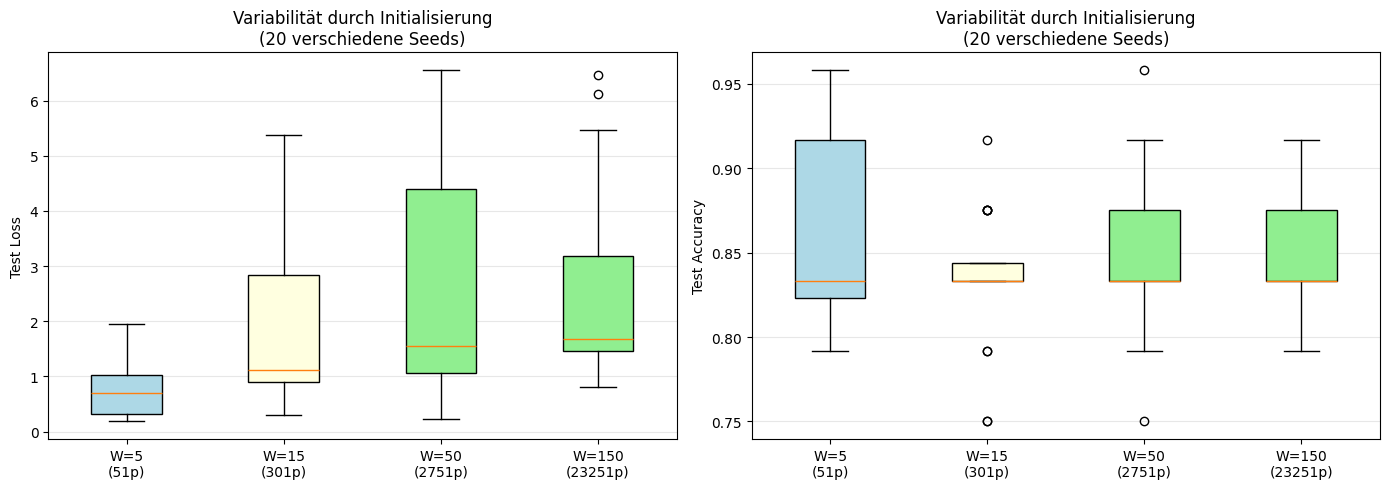


ERKENNTNIS:
───────────
• Die Varianz durch Initialisierung ist REAL aber meist überschaubar
• Größere Modelle: tendenziell stabiler (viele Wege zum Ziel)
• Am Interpolation-Punkt: höchste Varianz!
• → Wir MÜSSEN mehrere Seeds mitteln für zuverlässige Ergebnisse



In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# EXPERIMENT 2: EINFLUSS DER ZUFÄLLIGEN INITIALISIERUNG
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print("EXPERIMENT 2: Wie stark variiert das Ergebnis je nach Initialisierung?")
print("=" * 80)

def quick_train(model, X_train, y_train, X_test, y_test, epochs=3000, lr=0.01):
    """Schnelles Training, gibt nur finale Metriken zurück."""
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train).reshape(-1, 1)
    X_test_t = torch.FloatTensor(X_test)
    y_test_t = torch.FloatTensor(y_test).reshape(-1, 1)
    
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()
    
    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test_t), y_test_t).item()
        test_acc = ((model(X_test_t) > 0.5) == y_test_t).float().mean().item()
    
    return test_loss, test_acc

# Für jede Modellgröße: 20 verschiedene Seeds
n_seeds = 20
widths_to_test = [5, 15, 50, 150]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_by_width = {}

for width in widths_to_test:
    test_losses = []
    test_accs = []
    
    for seed in range(n_seeds):
        # Gleiche Daten, unterschiedliche Modell-Initialisierung
        torch.manual_seed(seed)
        model = ClassifierMLP(width)
        test_loss, test_acc = quick_train(model, X_train, y_train_noisy, X_test, y_test_true,
                                           epochs=3000)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
    
    results_by_width[width] = {
        'losses': test_losses,
        'accs': test_accs,
        'mean_loss': np.mean(test_losses),
        'std_loss': np.std(test_losses),
        'mean_acc': np.mean(test_accs),
        'std_acc': np.std(test_accs)
    }
    
    print(f"Width={width:3d}: Test Loss = {np.mean(test_losses):.4f} ± {np.std(test_losses):.4f}, "
          f"Test Acc = {np.mean(test_accs)*100:.1f}% ± {np.std(test_accs)*100:.1f}%")

# Boxplots
ax1 = axes[0]
bp1 = ax1.boxplot([results_by_width[w]['losses'] for w in widths_to_test],
                   labels=[f'W={w}\n({ClassifierMLP(w).n_params}p)' for w in widths_to_test],
                   patch_artist=True)
colors = ['lightblue', 'lightyellow', 'lightgreen', 'lightgreen']
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
ax1.set_ylabel('Test Loss')
ax1.set_title('Variabilität durch Initialisierung\n(20 verschiedene Seeds)', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')

ax2 = axes[1]
bp2 = ax2.boxplot([results_by_width[w]['accs'] for w in widths_to_test],
                   labels=[f'W={w}\n({ClassifierMLP(w).n_params}p)' for w in widths_to_test],
                   patch_artist=True)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
ax2.set_ylabel('Test Accuracy')
ax2.set_title('Variabilität durch Initialisierung\n(20 verschiedene Seeds)', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("""
ERKENNTNIS:
───────────
• Die Varianz durch Initialisierung ist REAL aber meist überschaubar
• Größere Modelle: tendenziell stabiler (viele Wege zum Ziel)
• Am Interpolation-Punkt: höchste Varianz!
• → Wir MÜSSEN mehrere Seeds mitteln für zuverlässige Ergebnisse
""")

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# NETZWERK FÜR KLASSIFIKATION
# ═══════════════════════════════════════════════════════════════════════════

class ClassifierMLP(nn.Module):
    """
    Einfaches MLP für binäre Klassifikation.
    Breite (width) kontrolliert die Modellkomplexität.
    """
    def __init__(self, width):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, width),      # Input: 2D Koordinaten
            nn.ReLU(),
            nn.Linear(width, width),  # Hidden Layer
            nn.ReLU(),
            nn.Linear(width, 1),      # Output: 1 Logit
            nn.Sigmoid()              # Wahrscheinlichkeit
        )
        self.n_params = sum(p.numel() for p in self.parameters())
        self.width = width
    
    def forward(self, x):
        return self.net(x)

Modellgrößen:
--------------------------------------------------
Width      Parameter       Regime (bei N=50)   
--------------------------------------------------
2          15              Underparameterized  
5          51              ≈ Interpolation     
10         151             Overparameterized   
20         501             Overparameterized   
50         2751            Overparameterized   
100        10501           Overparameterized   
200        41001           Overparameterized   


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# TRAINING FUNKTION
# ═══════════════════════════════════════════════════════════════════════════

def train_classifier(model, X_train, y_train, X_test, y_test, 
                     epochs=2000, lr=0.01):
    """
    Trainiert Klassifikator und gibt Accuracy + Loss zurück.
    """
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train).reshape(-1, 1)
    X_test_t = torch.FloatTensor(X_test)
    y_test_t = torch.FloatTensor(y_test).reshape(-1, 1)
    
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=0)  # Keine Regularisierung!
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()
    
    # Evaluation
    model.eval()
    with torch.no_grad():
        train_pred = model(X_train_t)
        test_pred = model(X_test_t)
        
        train_loss = criterion(train_pred, y_train_t).item()
        test_loss = criterion(test_pred, y_test_t).item()
        
        train_acc = ((train_pred > 0.5).float() == y_train_t).float().mean().item()
        test_acc = ((test_pred > 0.5).float() == y_test_t).float().mean().item()
    
    return train_loss, test_loss, train_acc, test_acc, model

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# HAUPTEXPERIMENT
# ═══════════════════════════════════════════════════════════════════════════

# Konfiguration
dataset_sizes = [30, 80, 200]      # Verschiedene Datensatzgrößen
widths = [2, 3, 4, 5, 7, 10, 15, 20, 30, 50, 75, 100, 150, 200]
label_noise = 0.0                  # 15% falsche Labels
n_repeats = 5                       # Wiederholungen für Stabilität

results = {}

print("=" * 70)
print("DOUBLE DESCENT EXPERIMENT - KLASSIFIKATION MIT LABEL NOISE")
print("=" * 70)
print(f"Label Noise: {label_noise*100:.0f}%")
print(f"Datensatzgrößen: {dataset_sizes}")
print(f"Netzwerk-Breiten: {widths}")
print("=" * 70)

for n_samples in dataset_sizes:
    print(f"\n{'─'*70}")
    print(f"DATENSATZ: {n_samples} Samples (Train: {int(n_samples*0.7)}, Test: {int (n_samples*0.3)})")
    print(f"{'─'*70}")
    
    results[n_samples] = {
        'params': [], 'widths': [],
        'train_loss': [], 'test_loss': [],
        'train_acc': [], 'test_acc': []
    }
    
    n_train = int(n_samples * 0.7)
    
    for width in widths:
        train_losses, test_losses = [], []
        train_accs, test_accs = [], []
        
        for rep in range(n_repeats):
            # Daten generieren
            np.random.seed(rep * 100 + n_samples)
            X, y_noisy, y_true = generate_noisy_moons(n_samples, noise=0.15, label_noise=label_noise)
            X_train, X_test, y_train, y_test = train_test_split(
                X, y_noisy, test_size=0.3, random_state=rep
            )
            
            # Für Test: wahre Labels verwenden (um Generalisierung fair zu messen)
            _, _, y_train_true, y_test_true = train_test_split(
                X, np.array([y_true[i] for i in range(len(y_true))]), 
                test_size=0.3, random_state=rep
            )
            
            # Modell trainieren
            torch.manual_seed(rep * 100)
            model = ClassifierMLP(width)
            tr_l, te_l, tr_a, te_a, _ = train_classifier(
                model, X_train, y_train, X_test, y_test_true.astype(np.float32),
                epochs=3000, lr=0.01
            )
            
            train_losses.append(tr_l)
            test_losses.append(te_l)
            train_accs.append(tr_a)
            test_accs.append(te_a)
        
        # Durchschnitte speichern
        n_params = ClassifierMLP(width).n_params
        results[n_samples]['params'].append(n_params)
        results[n_samples]['widths'].append(width)
        results[n_samples]['train_loss'].append(np.mean(train_losses))
        results[n_samples]['test_loss'].append(np.mean(test_losses))
        results[n_samples]['train_acc'].append(np.mean(train_accs))
        results[n_samples]['test_acc'].append(np.mean(test_accs))
        
        # Fortschritt
        marker = ""
        if abs(n_params - n_train) < n_train * 0.3:
            marker = " ◄── INTERPOLATION ZONE"
        print(f"  Width={width:3d} ({n_params:4d} params): "
              f"Test Loss={np.mean(test_losses):.4f}, "
              f"Test Acc={np.mean(test_accs)*100:.1f}%{marker}")

print("\n" + "=" * 70)
print("EXPERIMENT ABGESCHLOSSEN")
print("=" * 70)

DOUBLE DESCENT EXPERIMENT - KLASSIFIKATION MIT LABEL NOISE
Label Noise: 0%
Datensatzgrößen: [30, 80, 200]
Netzwerk-Breiten: [2, 3, 4, 5, 7, 10, 15, 20, 30, 50, 75, 100, 150, 200]

──────────────────────────────────────────────────────────────────────
DATENSATZ: 30 Samples (Train: 21, Test: 9)
──────────────────────────────────────────────────────────────────────
  Width=  2 (  15 params): Test Loss=0.4285, Test Acc=73.3% ◄── INTERPOLATION ZONE
  Width=  3 (  25 params): Test Loss=0.5500, Test Acc=71.1% ◄── INTERPOLATION ZONE
  Width=  4 (  37 params): Test Loss=0.7063, Test Acc=80.0%
  Width=  5 (  51 params): Test Loss=0.6109, Test Acc=77.8%
  Width=  7 (  85 params): Test Loss=2.8962, Test Acc=84.4%
  Width= 10 ( 151 params): Test Loss=5.0135, Test Acc=80.0%
  Width= 15 ( 301 params): Test Loss=6.3860, Test Acc=82.2%
  Width= 20 ( 501 params): Test Loss=3.1292, Test Acc=86.7%
  Width= 30 (1051 params): Test Loss=5.0114, Test Acc=86.7%
  Width= 50 (2751 params): Test Loss=1.0794, Test

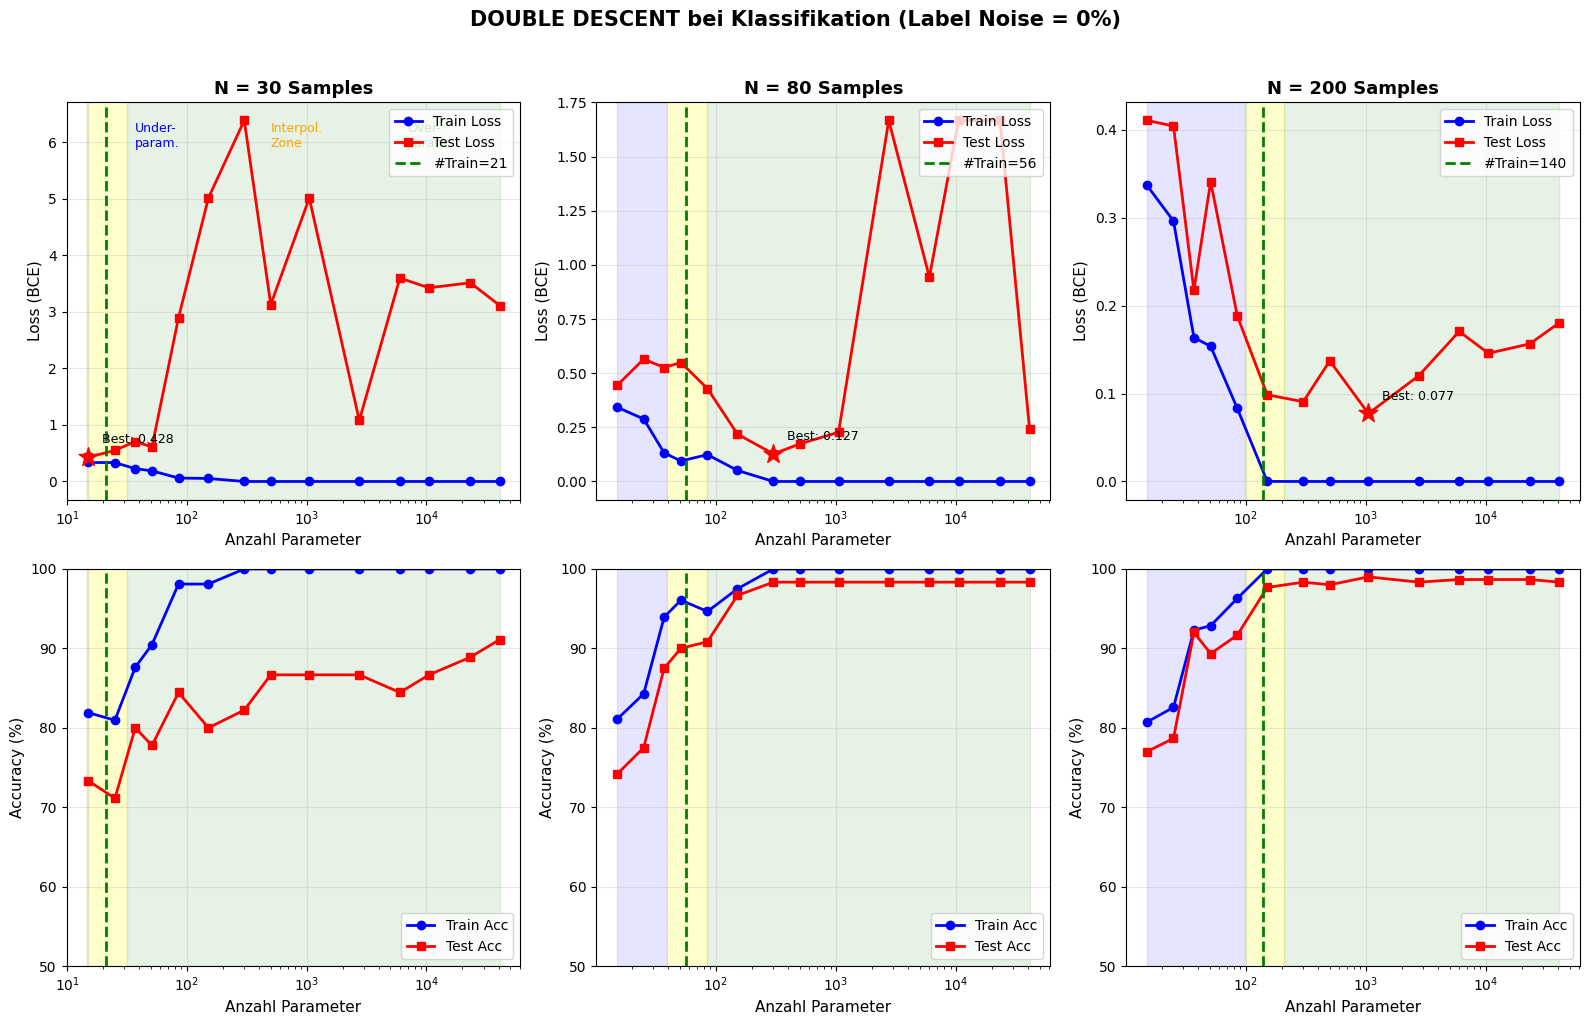

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# VISUALISIERUNG DER ERGEBNISSE
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col_idx, n_samples in enumerate(dataset_sizes):
    params = results[n_samples]['params']
    train_loss = results[n_samples]['train_loss']
    test_loss = results[n_samples]['test_loss']
    train_acc = results[n_samples]['train_acc']
    test_acc = results[n_samples]['test_acc']
    
    n_train = int(n_samples * 0.7)
    
    # ─── OBERE REIHE: LOSS ───
    ax1 = axes[0, col_idx]
    ax1.plot(params, train_loss, 'b-o', label='Train Loss', linewidth=2, markersize=6)
    ax1.plot(params, test_loss, 'r-s', label='Test Loss', linewidth=2, markersize=6)
    ax1.axvline(x=n_train, color='green', linestyle='--', linewidth=2, 
                label=f'#Train={n_train}')
    
    # Regime-Bereiche farbig hinterlegen
    ax1.axvspan(min(params), n_train*0.7, alpha=0.1, color='blue')
    ax1.axvspan(n_train*0.7, n_train*1.5, alpha=0.2, color='yellow')
    ax1.axvspan(n_train*1.5, max(params), alpha=0.1, color='green')
    
    ax1.set_xlabel('Anzahl Parameter', fontsize=11)
    ax1.set_ylabel('Loss (BCE)', fontsize=11)
    ax1.set_title(f'N = {n_samples} Samples', fontsize=13, fontweight='bold')
    ax1.set_xscale('log')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # Minimum markieren
    min_idx = np.argmin(test_loss)
    ax1.scatter([params[min_idx]], [test_loss[min_idx]], 
                color='red', s=200, marker='*', zorder=5)
    ax1.annotate(f'Best: {test_loss[min_idx]:.3f}', 
                 xy=(params[min_idx], test_loss[min_idx]),
                 xytext=(10, 10), textcoords='offset points', fontsize=9)
    
    # ─── UNTERE REIHE: ACCURACY ───
    ax2 = axes[1, col_idx]
    ax2.plot(params, [a*100 for a in train_acc], 'b-o', label='Train Acc', 
             linewidth=2, markersize=6)
    ax2.plot(params, [a*100 for a in test_acc], 'r-s', label='Test Acc', 
             linewidth=2, markersize=6)
    ax2.axvline(x=n_train, color='green', linestyle='--', linewidth=2)
    
    ax2.axvspan(min(params), n_train*0.7, alpha=0.1, color='blue')
    ax2.axvspan(n_train*0.7, n_train*1.5, alpha=0.2, color='yellow')
    ax2.axvspan(n_train*1.5, max(params), alpha=0.1, color='green')
    
    ax2.set_xlabel('Anzahl Parameter', fontsize=11)
    ax2.set_ylabel('Accuracy (%)', fontsize=11)
    ax2.set_xscale('log')
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([50, 100])
    
    # Regime-Beschriftungen
    if col_idx == 0:
        ax1.text(0.15, 0.95, 'Under-\nparam.', transform=ax1.transAxes, 
                 fontsize=9, verticalalignment='top', color='blue')
        ax1.text(0.45, 0.95, 'Interpol.\nZone', transform=ax1.transAxes, 
                 fontsize=9, verticalalignment='top', color='orange')
        ax1.text(0.75, 0.95, 'Over-\nparam.', transform=ax1.transAxes, 
                 fontsize=9, verticalalignment='top', color='green')

plt.suptitle(f'DOUBLE DESCENT bei Klassifikation (Label Noise = {label_noise*100:.0f}%)', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

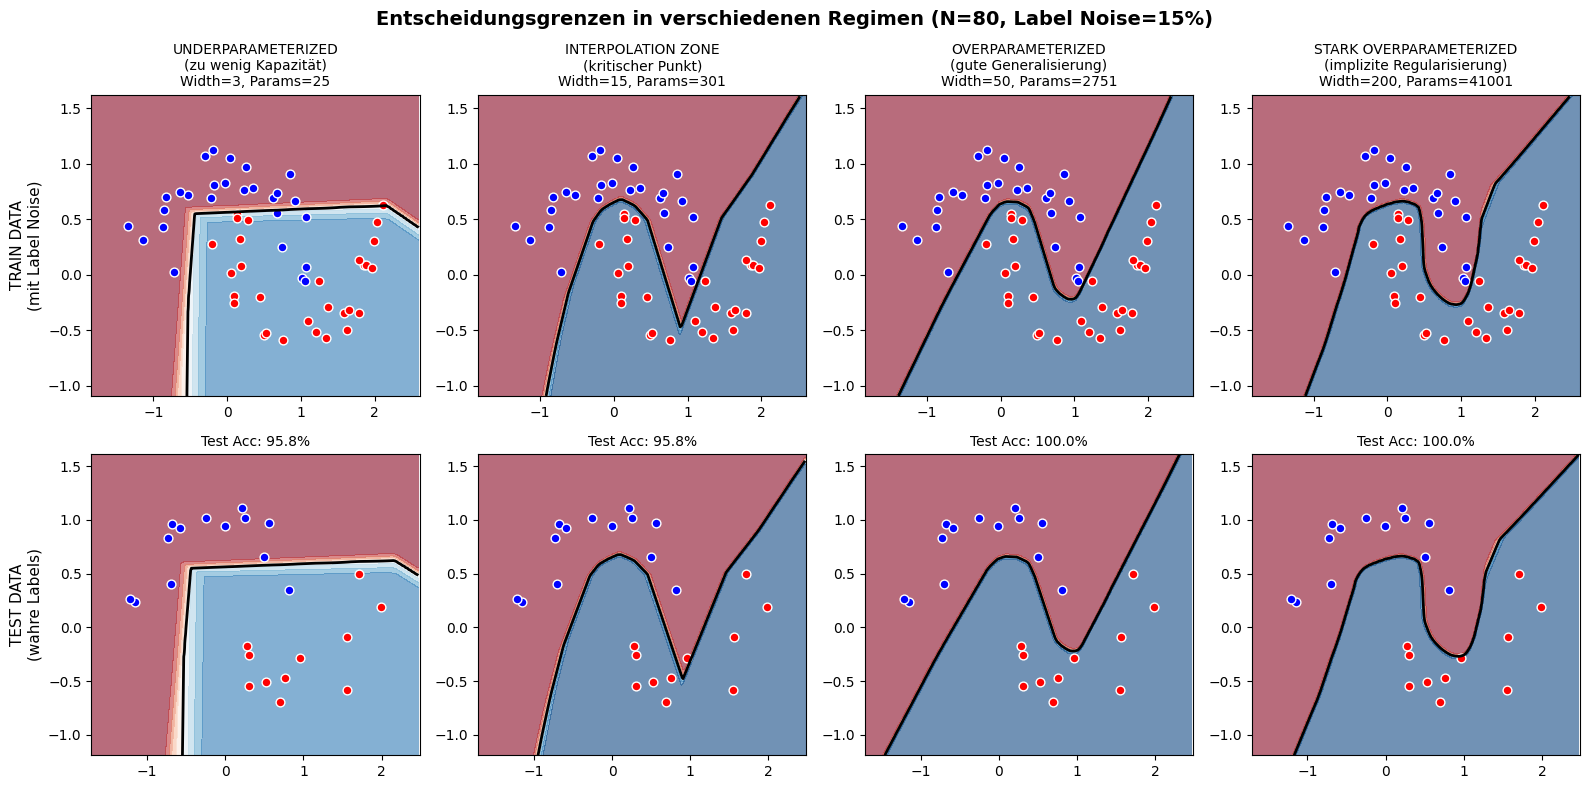


BEOBACHTUNGEN:
──────────────
1. UNDERPARAMETERIZED: Zu einfache Grenze, kann die Moons nicht trennen
2. INTERPOLATION ZONE: Versucht JEDEN Punkt richtig zu klassifizieren 
                       → "zackige" Grenze, die auch falschen Labels folgt!
3. OVERPARAMETERIZED:  Glatte Grenze trotz vieler Parameter
                       → Ignoriert effektiv die falschen Labels
4. STARK OVER:         Ähnlich glatt, implizite Regularisierung wirkt



In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# ENTSCHEIDUNGSGRENZEN VISUALISIEREN
# ═══════════════════════════════════════════════════════════════════════════

def plot_decision_boundary(model, X, y, ax, title):
    """Plottet die Entscheidungsgrenze eines Klassifikators."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
    
    model.eval()
    with torch.no_grad():
        Z = model(torch.FloatTensor(grid)).numpy()
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, levels=np.linspace(0, 1, 11), cmap='RdBu', alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    ax.scatter(X[y==0, 0], X[y==0, 1], c='blue', edgecolors='white', s=40)
    ax.scatter(X[y==1, 0], X[y==1, 1], c='red', edgecolors='white', s=40)
    ax.set_title(title, fontsize=10)
    ax.set_xlim([x_min, x_max])
    ax.set_ylim([y_min, y_max])

# Repräsentative Modelle für jedes Regime
n_samples = 80  # Mittlerer Datensatz
widths_demo = [3, 15, 50, 200]  # Under, Interpolation, Over, Sehr Over

np.random.seed(42)
X, y_noisy, y_true = generate_noisy_moons(n_samples, noise=0.15, label_noise=0.15)
X_train, X_test, y_train, y_test_true = train_test_split(
    X, y_true.astype(np.float32), test_size=0.3, random_state=42
)
_, _, y_train_noisy, _ = train_test_split(
    X, y_noisy, test_size=0.3, random_state=42
)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

regime_names = ['UNDERPARAMETERIZED\n(zu wenig Kapazität)', 
                'INTERPOLATION ZONE\n(kritischer Punkt)', 
                'OVERPARAMETERIZED\n(gute Generalisierung)',
                'STARK OVERPARAMETERIZED\n(implizite Regularisierung)']

for idx, width in enumerate(widths_demo):
    torch.manual_seed(42)
    model = ClassifierMLP(width)
    n_params = model.n_params
    
    # Training auf verrauschten Labels
    _, test_loss, _, test_acc, trained_model = train_classifier(
        model, X_train, y_train_noisy, X_test, y_test_true,
        epochs=3000, lr=0.01
    )
    
    # Obere Reihe: Trainingsdaten
    plot_decision_boundary(trained_model, X_train, y_train_noisy, axes[0, idx],
                          f'{regime_names[idx]}\nWidth={width}, Params={n_params}')
    axes[0, idx].set_xlabel('')
    if idx == 0:
        axes[0, idx].set_ylabel('TRAIN DATA\n(mit Label Noise)', fontsize=11)
    
    # Untere Reihe: Testdaten
    plot_decision_boundary(trained_model, X_test, y_test_true, axes[1, idx],
                          f'Test Acc: {test_acc*100:.1f}%')
    if idx == 0:
        axes[1, idx].set_ylabel('TEST DATA\n(wahre Labels)', fontsize=11)

plt.suptitle(f'Entscheidungsgrenzen in verschiedenen Regimen (N={n_samples}, Label Noise=15%)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
BEOBACHTUNGEN:
──────────────
1. UNDERPARAMETERIZED: Zu einfache Grenze, kann die Moons nicht trennen
2. INTERPOLATION ZONE: Versucht JEDEN Punkt richtig zu klassifizieren 
                       → "zackige" Grenze, die auch falschen Labels folgt!
3. OVERPARAMETERIZED:  Glatte Grenze trotz vieler Parameter
                       → Ignoriert effektiv die falschen Labels
4. STARK OVER:         Ähnlich glatt, implizite Regularisierung wirkt
""")

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# VERGLEICH: MIT vs. OHNE LABEL NOISE
# ═══════════════════════════════════════════════════════════════════════════

print("\nZUSATZ-EXPERIMENT: Einfluss von Label Noise auf Double Descent")
print("=" * 70)

noise_levels = [0.0, 0.15, 0.30]
n_samples = 80
widths = [2, 3, 5, 7, 10, 15, 20, 30, 50, 75, 100, 150, 200]

noise_results = {}

for label_noise in noise_levels:
    print(f"\nLabel Noise = {label_noise*100:.0f}%...")
    noise_results[label_noise] = {'params': [], 'test_loss': []}
    
    for width in widths:
        test_losses = []
        
        for rep in range(5):
            np.random.seed(rep * 100)
            X, y_noisy, y_true = generate_noisy_moons(n_samples, noise=0.15, label_noise=label_noise)
            X_train, X_test, y_train, y_test_true = train_test_split(
                X, y_true.astype(np.float32), test_size=0.3, random_state=rep
            )
            _, _, y_train_noisy, _ = train_test_split(
                X, y_noisy, test_size=0.3, random_state=rep
            )
            
            torch.manual_seed(rep)
            model = ClassifierMLP(width)
            _, te_l, _, _, _ = train_classifier(
                model, X_train, y_train_noisy, X_test, y_test_true,
                epochs=3000, lr=0.01
            )
            test_losses.append(te_l)
        
        noise_results[label_noise]['params'].append(ClassifierMLP(width).n_params)
        noise_results[label_noise]['test_loss'].append(np.mean(test_losses))

# Visualisierung
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['green', 'orange', 'red']
for idx

SyntaxError: invalid syntax (3761585534.py, line 46)